# **Universidad Autónoma de Sinaloa**
**Facultad de Ciencias Físico-Matemáticas**
**Diplomado** en *Estadística para Ciencia de Datos*
<br>
Métodos Multivariados.
Módulo IV – Tarea 01

Análisis de conglomerados y clasificación.  


Dr. Marco Tulio Gaxiola Leyva.  

Dra. Norma Selomit Ramírez Uribe.  


Ángel Félix Velarde

<br>

Fecha  

Sabado 24 de enero de 2026.

En este trabajo aplicaremos lo aprendido en Módulo 4 - Modelos Multivariados, en este caso a analizaremos los métodos de clustering y de K-means en el primer problema para el segundo se usará el método de Linear Discriminant Analysis.

\pagenumbering{gobble}

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
import geopandas as gpd
import requests, zipfile, io

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

from scipy.spatial.distance import euclidean
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Problema 1. Métodos de agrupación.

Utilizaremos el dataset USArrest para hacer un análisis de cluestring sobre los délitos de los 50 estados en Estados Unidos. <br>

Primero abriremos el dataset y cargaremos algunos renglones para entender el mismo.

In [3]:

# Cargamos el conjunto de datos desde una URL publica
url = "https://raw.githubusercontent.com/selva86/datasets/master/USArrests.csv"
df = pd.read_csv(url)

In [4]:
df.head(5)

,Murder,Assault,UrbanPop,Rape,State
0,13.2,236,58,21.2,Alabama
1,10.0,263,48,44.5,Alaska
2,8.1,294,80,31.0,Arizona
3,8.8,190,50,19.5,Arkansas
4,9.0,276,91,40.6,California


Se observa que el dataset contiene cinco columnas **Murder**, **Assault**, **UrbanPop**, **Rape** y **State**. <br>
Los primeros cuatro son númericos y el quinto es la etiqueta del nombre del estado.

Utilizaremos el comando *describe* para ver como se comportan nuestros datos.

In [7]:
df.describe()

,Murder,Assault,UrbanPop,Rape
count,50.00000,50.000000,50.000000,50.000000
mean,7.78800,170.760000,65.540000,21.232000
std,4.35551,83.337661,14.474763,9.366385
min,0.80000,45.000000,32.000000,7.300000
25%,4.07500,109.000000,54.500000,15.075000
50%,7.25000,159.000000,66.000000,20.100000
75%,11.25000,249.000000,77.750000,26.175000
max,17.40000,337.000000,91.000000,46.000000


Se puede observar que la columna **Assault** absorbe la mayoría de la información. <br>
La media de **Assault** es el doble que la segunda mayor, en este caso, **UrbanPop**.


Ahora se eliminará la columna **State** para quedarnos solo con datos númericos.



In [8]:
df_number = df.drop(columns=['State'])
df_number.head(5)

,Murder,Assault,UrbanPop,Rape
0,13.2,236,58,21.2
1,10.0,263,48,44.5
2,8.1,294,80,31.0
3,8.8,190,50,19.5
4,9.0,276,91,40.6


Como los datos que se tienen no son normalizados, aplicaremos la estandarización de los mismos. <br>
Considerando lo siguiente.
$$
\mu = 0, \quad \sigma^2 = 1
$$

In [9]:
# Matriz de datos con variables en escalas distintas
# Reset the index to make 'Murder' a regular column for standardization
X = df_number

# Estandarizacion: media 0 y varianza 1
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# Distancia euclidiana con datos estandarizados
dist_con = euclidean(X_std[0], X_std[1])
print("Distancia estandarizada:", dist_con)
print(f"Shape of X_std after standardization: {X_std.shape}")

Distancia estandarizada: 2.7312040564094446
Shape of X_std after standardization: (50, 4)


In [10]:
df_number_std = pd.DataFrame(X_std)
df_number_std.head(5)

,0,1,2,3
0,1.255179,0.790787,-0.526195,-0.003451
1,0.513019,1.118060,-1.224067,2.509424
2,0.072361,1.493817,1.009122,1.053466
3,0.234708,0.233212,-1.084492,-0.186794
4,0.281093,1.275635,1.776781,2.088814


## Dendrograma

Se hará un *dendrograma* para agrupar los estados según su cercania usando la distancia euclideana.

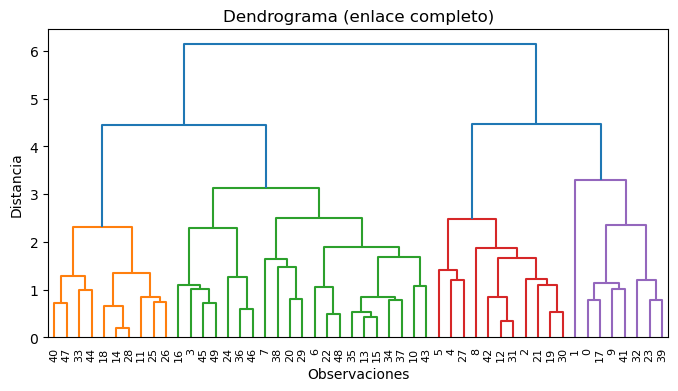

In [11]:
# Generamos 9 observaciones en un espacio bidimensional
datos = df_number_std

# Construimos la matriz de enlace usando enlace completo
dendo = linkage(datos, method='complete', metric='euclidean')
#print(dendo)

plt.figure(figsize=(8, 4))
dendrogram(dendo)
plt.title("Dendrograma (enlace completo)")
plt.xlabel("Observaciones")
plt.ylabel("Distancia")

# Guardar figura
plt.savefig("Dendrograma.png", dpi=300, bbox_inches="tight")

plt.show()

En el dendrograma se puede observar la particularidad de que se forman cuatro clusters.

In [12]:
# Cut the dendrogram to get 4 clusters
num_clusters = 4
clusters = fcluster(dendo, num_clusters, criterion='maxclust')

# Create a DataFrame with standardized data and cluster assignments
clustered_df_std = pd.DataFrame(X_std, columns=X.columns)
clustered_df_std['Cluster'] = clusters

# Map cluster numbers to specified colors
color_map = {
    1: 'orange',
    2: 'green',
    3: 'red',
    4: 'purple'
}

# Add original state names and corresponding colors to the DataFrame
clustered_df_std['State'] = df['State'].values
clustered_df_std['Color'] = clustered_df_std['Cluster'].map(color_map)

# Print the desired information
print("Cluster Assignments:")
print(clustered_df_std[['State', 'Cluster', 'Color']].to_string(index=False))

Cluster Assignments:
         State  Cluster  Color
       Alabama        4 purple
        Alaska        4 purple
       Arizona        3    red
      Arkansas        2  green
    California        3    red
      Colorado        3    red
   Connecticut        2  green
      Delaware        2  green
       Florida        3    red
       Georgia        4 purple
        Hawaii        2  green
         Idaho        1 orange
      Illinois        3    red
       Indiana        2  green
          Iowa        1 orange
        Kansas        2  green
      Kentucky        2  green
     Louisiana        4 purple
         Maine        1 orange
      Maryland        3    red
 Massachusetts        2  green
      Michigan        3    red
     Minnesota        2  green
   Mississippi        4 purple
      Missouri        2  green
       Montana        1 orange
      Nebraska        1 orange
        Nevada        3    red
 New Hampshire        1 orange
    New Jersey        2  green
    New Mexico    

Unmatched states: []


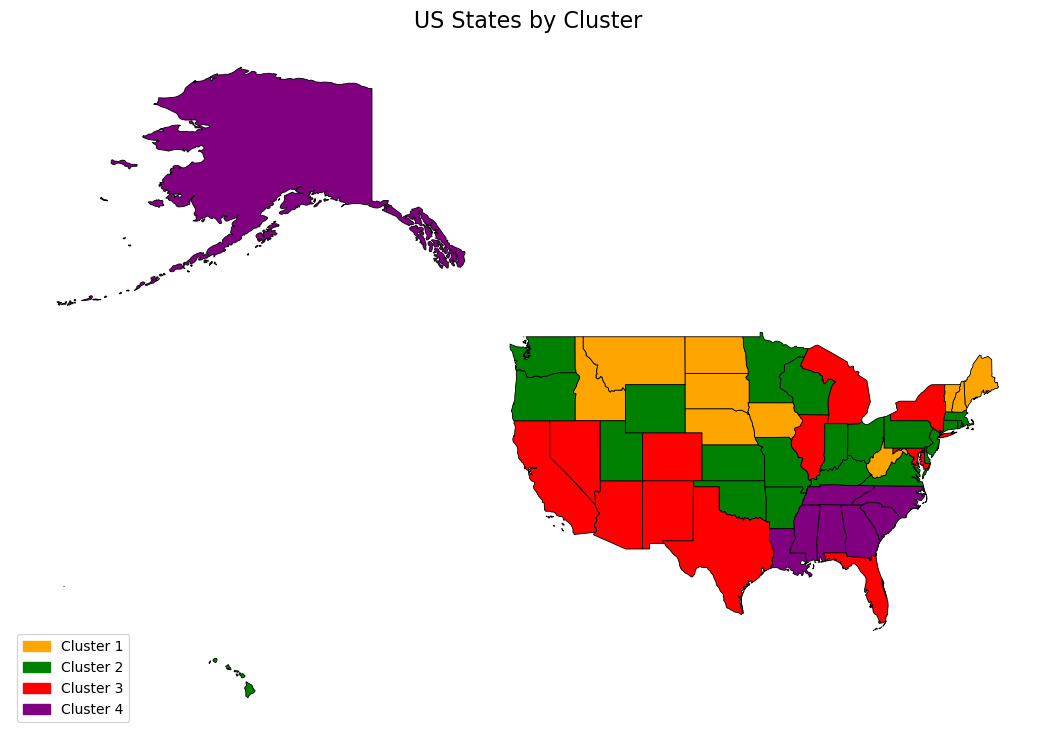

In [13]:
# Download shapefile
url = "https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_1_states_provinces.zip"
r = requests.get(url)

with zipfile.ZipFile(io.BytesIO(r.content)) as z:
    z.extractall("us_states")

# Load data
states = gpd.read_file("us_states/ne_50m_admin_1_states_provinces.shp")

# Keep ONLY real US states
states = states[
    (states["admin"] == "United States of America") &
    (states["type"] == "State")
]

states["state"] = states["name_en"].str.strip()

# ---- CLUSTERS (FIXED) ----
clusters = {
    1: [
        "Idaho", "Iowa", "Maine", "Montana", "Nebraska",
        "New Hampshire", "North Dakota", "South Dakota",
        "Vermont", "West Virginia"
    ],
    2: [
        "Arkansas", "Connecticut", "Delaware", "Hawaii", "Indiana",
        "Kansas", "Kentucky", "Massachusetts", "Minnesota", "Missouri",
        "New Jersey", "Ohio", "Oklahoma", "Oregon",
        "Pennsylvania", "Rhode Island", "Utah", "Virginia",
        "Washington", "Wisconsin", "Wyoming"
    ],
    3: [
        "Arizona", "California", "Colorado", "Florida",
        "Illinois", "Maryland", "Michigan", "Nevada",
        "New Mexico", "New York", "Texas"
    ],
    4: [
        "Alabama", "Alaska", "Georgia", "Louisiana",
        "Mississippi", "North Carolina",
        "South Carolina", "Tennessee"
    ]
}


# Assign cluster
def assign_cluster(state):
    for c, lst in clusters.items():
        if state in lst:
            return c
    return None

states["cluster"] = states["state"].apply(assign_cluster)

# Colors
color_map = {
    1: "orange",
    2: "green",
    3: "red",
    4: "purple"
}

states["color"] = states["cluster"].map(color_map).fillna("lightgray")

# Debug unmatched
print("Unmatched states:",
      states.loc[states["cluster"].isna(), "state"].tolist())

# ---- PLOT ----
fig, ax = plt.subplots(figsize=(14, 9))

states.plot(
    color=states["color"],
    edgecolor="black",
    linewidth=0.6,
    ax=ax
)

ax.set_title("US States by Cluster", fontsize=16)
ax.axis("off")

legend_patches = [
    mpatches.Patch(color="orange", label="Cluster 1"),
    mpatches.Patch(color="green", label="Cluster 2"),
    mpatches.Patch(color="red", label="Cluster 3"),
    mpatches.Patch(color="purple", label="Cluster 4"),
]

ax.legend(handles=legend_patches, loc="lower left")
plt.show()

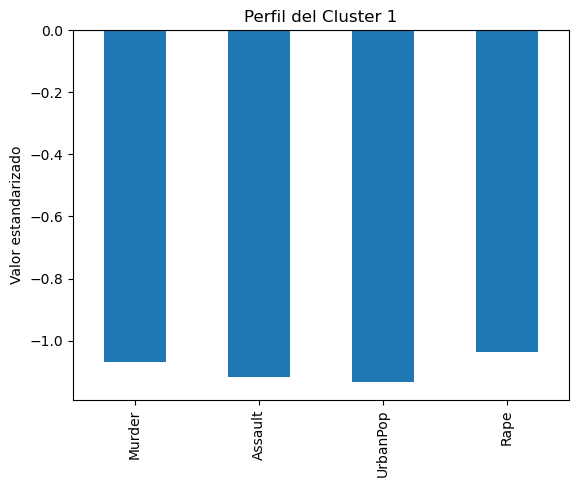

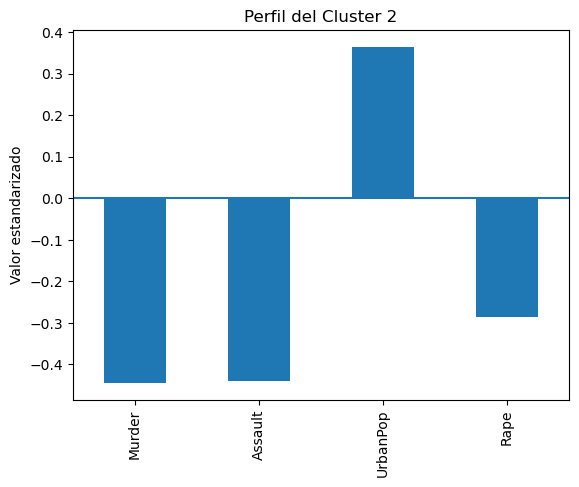

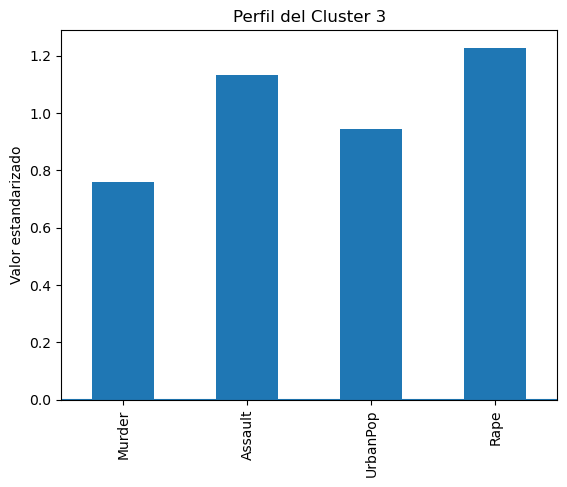

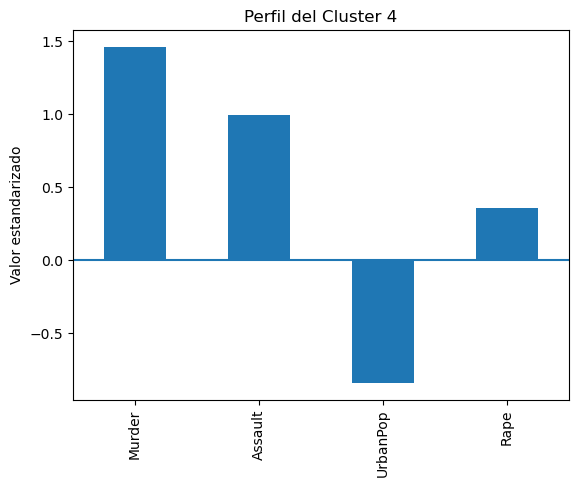

In [14]:
for c in sorted(clustered_df_std["Cluster"].unique()):
    means = (
        clustered_df_std
        .loc[clustered_df_std["Cluster"] == c, X.columns]
        .mean()
    )
    
    plt.figure()
    means.plot(kind="bar")
    plt.axhline(0)
    plt.title(f"Perfil del Cluster {c}")
    plt.ylabel("Valor estandarizado")
    plt.show()

Con las gráficas anteriores podemos agrupar a los cluster en cuatro categorias, basadas en su población urbana y la criminalidad de los estados. <br>
Con los valores del promedio de la criminalidad y la poblacion urbana generaremos la siguiente gráfica que nos permitirá vislumbrar mejor lo anterior.

In [15]:
# Variables criminales
crime_vars = ["Murder", "Assault", "Rape"]

# Eje X: índice criminal (promedio de variables estandarizadas)
clustered_df_std["Crime_Index"] = clustered_df_std[crime_vars].mean(axis=1)

clustered_df_std["UrbanPop_std"] = clustered_df_std["UrbanPop"]

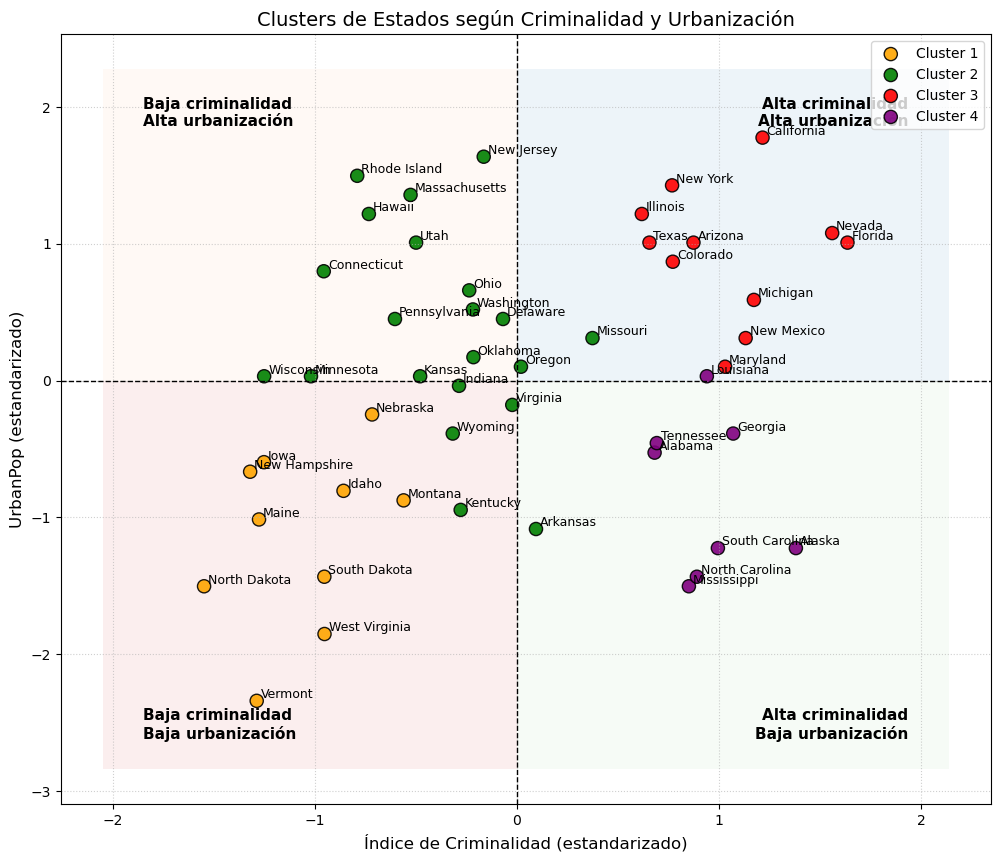

In [16]:
plt.figure(figsize=(12, 10))

# Límites del gráfico
xmin, xmax = clustered_df_std["Crime_Index"].min() - 0.5, clustered_df_std["Crime_Index"].max() + 0.5
ymin, ymax = clustered_df_std["UrbanPop_std"].min() - 0.5, clustered_df_std["UrbanPop_std"].max() + 0.5

# Cuadrantes (sombreado suave)
plt.fill_betweenx([0, ymax], 0, xmax, alpha=0.08)
plt.fill_betweenx([0, ymax], xmin, 0, alpha=0.04)
plt.fill_betweenx([ymin, 0], 0, xmax, alpha=0.04)
plt.fill_betweenx([ymin, 0], xmin, 0, alpha=0.08)

# Scatter por cluster
for c in sorted(clustered_df_std["Cluster"].unique()):
    subset = clustered_df_std[clustered_df_std["Cluster"] == c]
    
    plt.scatter(
        subset["Crime_Index"],
        subset["UrbanPop_std"],
        c=subset["Color"],
        label=f"Cluster {c}",
        edgecolors="black",
        s=90,
        alpha=0.9
    )
    
    # Etiquetas de los estados
    for _, row in subset.iterrows():
        plt.text(
            row["Crime_Index"] + 0.02,
            row["UrbanPop_std"] + 0.02,
            row["State"],
            fontsize=9
        )

# Líneas centrales
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.axvline(0, color="black", linestyle="--", linewidth=1)

# Texto de los cuadrantes
plt.text(xmax - 0.2, ymax - 0.2, "Alta criminalidad\nAlta urbanización",
         ha="right", va="top", fontsize=11, weight="bold")

plt.text(xmin + 0.2, ymax - 0.2, "Baja criminalidad\nAlta urbanización",
         ha="left", va="top", fontsize=11, weight="bold")

plt.text(xmax - 0.2, ymin + 0.2, "Alta criminalidad\nBaja urbanización",
         ha="right", va="bottom", fontsize=11, weight="bold")

plt.text(xmin + 0.2, ymin + 0.2, "Baja criminalidad\nBaja urbanización",
         ha="left", va="bottom", fontsize=11, weight="bold")

# Etiquetas y título
plt.xlabel("Índice de Criminalidad (estandarizado)", fontsize=12)
plt.ylabel("UrbanPop (estandarizado)", fontsize=12)
plt.title("Clusters de Estados según Criminalidad y Urbanización", fontsize=14)
plt.legend(frameon=True)
plt.grid(True, linestyle=":", alpha=0.6)

plt.show()


Entonces se puede identificar lo siguiente: <br>
**\textcolor{gold}{\textbf{Cluster}}: Baja criminalidad y baja urbanización**

Este \textcolor{gold}{cluster} agrupa estados que presentan valores consistentemente por debajo del promedio nacional tanto en el índice de criminalidad como en el porcentaje de población urbana. Su localización en el cuadrante inferior izquierdo del plano confirma que el algoritmo de clustering jerárquico identifica un perfil de baja incidencia criminal asociado a menor urbanización. <br>

**\textcolor{green}{\textbf{Cluster}}: Baja criminalidad y alta urbanización**

Este \textcolor{green}{cluster} agrupa estados que presentan un valor consistentemente por debajo del promedio nacional en el índice de criminalidad y por arriba del promedio general en cuanto a población urbana. Su localización en el cuadrante superior izquierdo del plano confirma que el algoritmo de clustering jerárquico identifica un perfil de baja incidencia criminal asociado a alta urbanización. <br>

**\textcolor{purple}{\textbf{Cluster}}: Alta criminalidad y baja urbanización**

Este \textcolor{purple}{cluster} agrupa estados que presentan valores consistentemente por debajo del promedio nacional tanto en el índice de urbanización y un índice de criminalidad arriba del promedio. Su localización en el cuadrante inferior derecho del plano confirma que el algoritmo de clustering jerárquico identifica un perfil de alta incidencia criminal asociado a menor urbanización. <br>

**\textcolor{red}{\textbf{Cluster}}: Alta criminalidad y alta urbanización**

Este \textcolor{red}{cluster} agrupa estados que presentan valores consistentemente por arriba del promedio nacional tanto en el índice de criminalidad como en el porcentaje de población urbana. Su localización en el cuadrante superior derecha del plano confirma que el algoritmo de clustering jerárquico identifica un perfil de alta incidencia criminal asociado a mayor urbanización. <br>

## K-means.

Se mostrarán de nuevo los datos númericos de **USArrest**.

In [18]:
df_number_k = df.drop(columns=['State'])
df_number_k.head(5)

,Murder,Assault,UrbanPop,Rape
0,13.2,236,58,21.2
1,10.0,263,48,44.5
2,8.1,294,80,31.0
3,8.8,190,50,19.5
4,9.0,276,91,40.6


In [19]:
# Matriz de datos con variables en escalas distintas
# Reset the index to make 'Murder' a regular column for standardization
X_k = df_number_k

# Estandarizacion: media 0 y varianza 1
scaler = StandardScaler()
X_std_k = scaler.fit_transform(X_k)

# Distancia euclidiana con datos estandarizados
dist_con = euclidean(X_std_k[0], X_std_k[1])
print("Distancia estandarizada:", dist_con)
print(f"Shape of X_std after standardization: {X_std.shape}")

Distancia estandarizada: 2.7312040564094446
Shape of X_std after standardization: (50, 4)


Con los datos estandarizados usaremos la gráfica de *Elbow Method* para mostrarnos cuantas agrupaciones hacer.

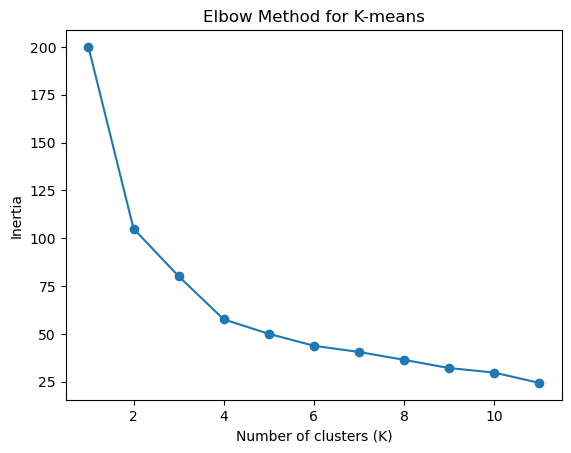

In [20]:
inertia = []
K_range = range(1, 12)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=9, n_init=10)
    km.fit(X_std)
    inertia.append(km.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for K-means')
plt.show()

Podemos observar el codo de nuestra gráfica está entre el número 4 y 6. <br>
Por temas de análisis se escogerá el 4 para tener el mismo número de cluster que con el método del dendrograma.

In [21]:
kmeans = KMeans(
    n_clusters=4,
    random_state=9,
    n_init=10
)

clusters = kmeans.fit_predict(X_std_k)

In [22]:
data_k = df_number_std
data_k.head(5)

,0,1,2,3
0,1.255179,0.790787,-0.526195,-0.003451
1,0.513019,1.118060,-1.224067,2.509424
2,0.072361,1.493817,1.009122,1.053466
3,0.234708,0.233212,-1.084492,-0.186794
4,0.281093,1.275635,1.776781,2.088814


In [23]:
data_k['Cluster'] = clusters
data_k[['Cluster']].value_counts().sort_index()

Cluster
0           8
1          16
2          13
3          13
Name: count, dtype: int64

Con los cluster se generó un mapa de los Estados Unidos.

Unmatched states: []


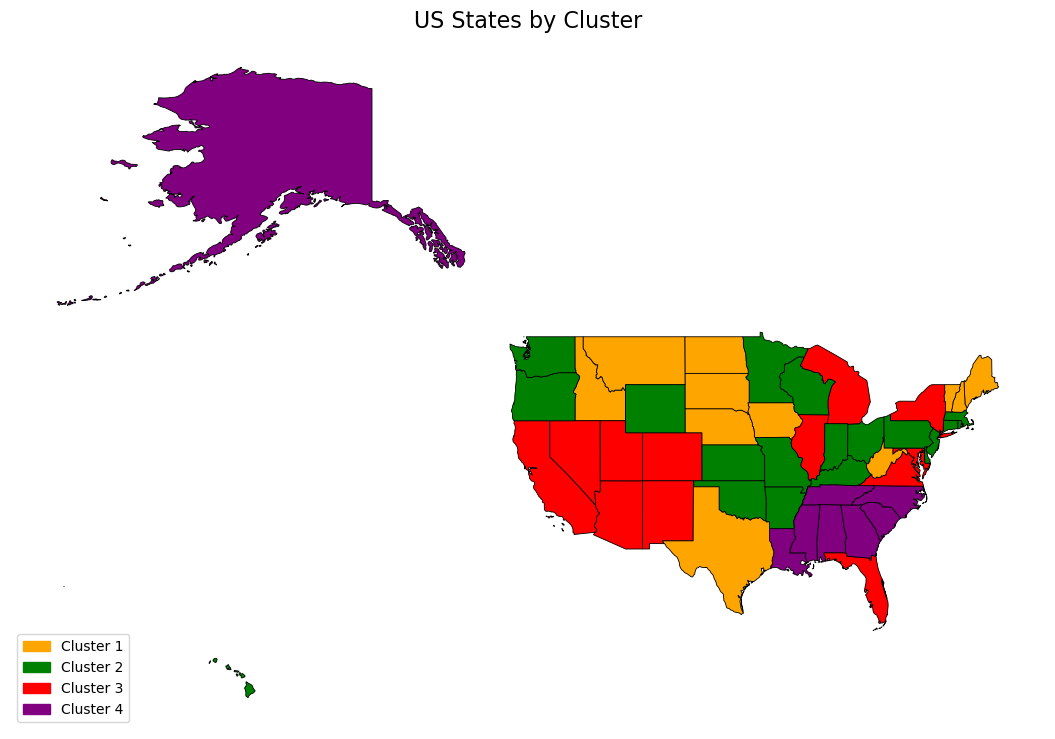

In [24]:
# Download shapefile
url = "https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_1_states_provinces.zip"
r = requests.get(url)

with zipfile.ZipFile(io.BytesIO(r.content)) as z:
    z.extractall("us_states")

# Load data
states = gpd.read_file("us_states/ne_50m_admin_1_states_provinces.shp")

# Keep ONLY real US states
states = states[
    (states["admin"] == "United States of America") &
    (states["type"] == "State")
]

states["state"] = states["name_en"].str.strip()

# ---- CLUSTERS (FIXED) ----
clusters = {
    1: [
        "Idaho", "Iowa", "Maine", "Montana", "Nebraska",
        "New Hampshire", "North Dakota", "South Dakota", "Texas", "Vermont",
        "West Virginia"
    ],
    2: [
        "Arkansas", "Connecticut", "Delaware", "Hawaii", "Indiana",
        "Kansas", "Kentucky", "Massachusetts", "Minnesota", "Missouri",
        "New Jersey", "Ohio", "Oklahoma", "Oregon",
        "Pennsylvania", "Rhode Island", "Washington", "Wisconsin", "Wyoming"
    ],
    3: [
        "Arizona", "California", "Colorado", "Florida",
        "Illinois", "Maryland", "Michigan", "Nevada",
        "New Mexico", "New York", "Utah", "Virginia"
    ],
    4: [
        "Alabama", "Alaska", "Georgia", "Louisiana",
        "Mississippi", "North Carolina",
        "South Carolina", "Tennessee"
    ]
}

# Assign cluster
def assign_cluster(state):
    for c, lst in clusters.items():
        if state in lst:
            return c
    return None

states["cluster"] = states["state"].apply(assign_cluster)

# Colors
color_map = {
    1: "orange",
    2: "green",
    3: "red",
    4: "purple"
}

states["color"] = states["cluster"].map(color_map).fillna("lightgray")

# Debug unmatched
print("Unmatched states:",
      states.loc[states["cluster"].isna(), "state"].tolist())

# ---- PLOT ----
fig, ax = plt.subplots(figsize=(14, 9))

states.plot(
    color=states["color"],
    edgecolor="black",
    linewidth=0.6,
    ax=ax
)

ax.set_title("US States by Cluster", fontsize=16)
ax.axis("off")

legend_patches = [
    mpatches.Patch(color="orange", label="Cluster 1"),
    mpatches.Patch(color="green", label="Cluster 2"),
    mpatches.Patch(color="red", label="Cluster 3"),
    mpatches.Patch(color="purple", label="Cluster 4"),
]

ax.legend(handles=legend_patches, loc="lower left")
plt.show()


Entonces se puede identificar lo siguiente: <br><br>

**\textcolor{gold}{\textbf{Cluster}}: Alta criminalidad y baja urbanización.**

Este \textcolor{gold}{Cluster} agrupa estados que presentan valores consistentemente por encima del promedio nacional en el índice de criminalidad, combinados con niveles de urbanización por debajo de la media. Su localización en el cuadrante inferior derecho del plano confirma que el algoritmo K-means identifica un perfil de alta incidencia criminal que no está asociado a altos niveles de urbanización, lo que sugiere la presencia de factores estructurales distintos a los propios de los grandes centros urbanos. <br><br>

**\textcolor{green}{\textbf{Cluster}}: Baja criminalidad y alta urbanización.**

Este \textcolor{green}{Cluster} agrupa estados que presentan valores por debajo del promedio nacional en el índice de criminalidad y por encima del promedio en el porcentaje de población urbana. Su localización en el cuadrante superior izquierdo del plano indica que K-means identifica un perfil de baja incidencia criminal asociado a altos niveles de urbanización, característico de estados con mayor desarrollo urbano y mejor control de la criminalidad. <br><br>

**\textcolor{red}{\textbf{Cluster}}: Baja criminalidad y baja urbanización.**

Este \textcolor{red}{Cluster} agrupa estados que presentan valores por debajo del promedio nacional tanto en el índice de criminalidad como en el nivel de urbanización. Su ubicación en el cuadrante inferior izquierdo del plano confirma que el algoritmo K-means identifica un perfil de baja incidencia criminal asociado a contextos menos urbanizados, generalmente correspondientes a estados con baja densidad poblacional y menor actividad urbana. <br><br>

**\textcolor{purple}{\textbf{Cluster}}: Alta criminalidad y alta urbanización**

Este \textcolor{purple}{Cluster} agrupa estados que presentan valores por encima del promedio nacional tanto en el índice de criminalidad como en el porcentaje de población urbana. Su localización en el cuadrante superior derecho del plano confirma que K-means identifica un perfil de alta incidencia criminal asociado a altos niveles de urbanización, característico de estados altamente poblados y con grandes áreas metropolitanas. <br>

# Problema 2. Discriminant Analysis.

In [25]:
vino = load_wine()

X_vino = pd.DataFrame(vino.data, columns=vino.feature_names)
y_vino = pd.Series(vino.target, name='wine_class')

#vino.target_names

Con la funcion *describe* se mostrará información de la media y desviación de los datos númericos de nuestra tabla de vinos.

In [26]:
X_vino.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


Se usarán gráficas de *Box Plot* divididas según categoría de vino para darnos un vistazo significativo.

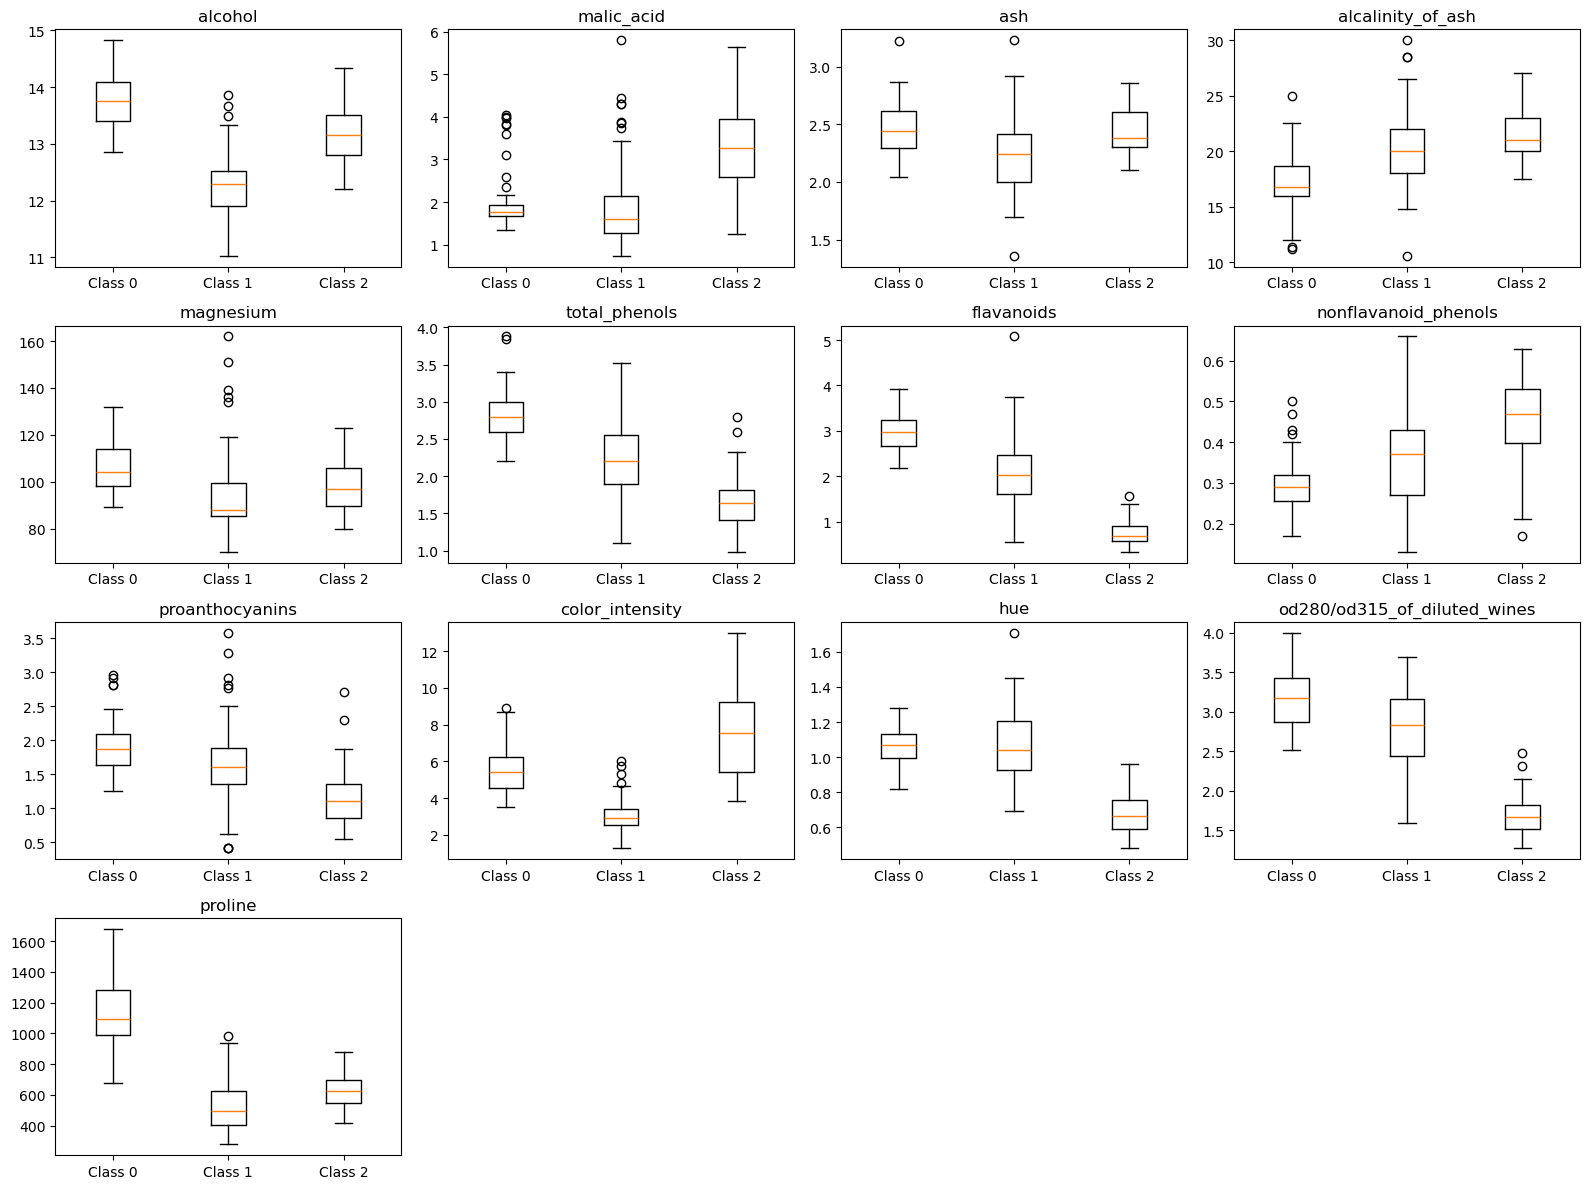

In [27]:
classes = np.unique(y_vino)
n_vars = X_vino.shape[1]
n_cols = 4
n_rows = (n_vars // n_cols) + 1

plt.figure(figsize=(16, 3*n_rows))

for i, col in enumerate(X_vino.columns, 1):
    plt.subplot(n_rows, n_cols, i)

    data_by_class = [
        X_vino.loc[y_vino == c, col]
        for c in classes
    ]

    plt.boxplot(
    data_by_class,
    labels=[f'Class {c}' for c in classes]
)
    plt.title(col)
    plt.tight_layout()

plt.show()

De los múltiples boxplot se puede llegar a una conclusión rápida: "las medias de las categorías difieren bastante en cada una", lo cual nos puede llegar a pensar que la clasificación es sencilla. <br>

Ahora haremos el análisis de clasificación mediante el **Linear Discrminant Analysis** <br>

Se hará la estandarización de los datos, el entrenamiento y los ajustes necesarios para la aplicación del LDA.

$$
f_k(x)
=
\frac{1}{(2\pi)^{p/2}|\Sigma|^{1/2}}
\exp\left(
-\frac{1}{2}(x-\mu_k)^T \Sigma^{-1} (x-\mu_k)
\right)
$$

In [28]:
scaler = StandardScaler()
X_std_vino = scaler.fit_transform(X_vino)

In [29]:
X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(
    X_std_vino, y_vino, test_size=0.2, random_state=9
)

In [30]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_v, y_train_v)


LinearDiscriminantAnalysis()

In [31]:
lda.fit(X_vino, y_vino)

LinearDiscriminantAnalysis()

In [32]:
# Varianza explicada por cada componente
explained_var = lda.explained_variance_ratio_

print("Varianza explicada:", explained_var)

# Evaluar desempeño para p = 1 y p = 2
accuracies = {}

for p in [1, 2]:
    lda_p = LinearDiscriminantAnalysis(n_components=p)
    lda_p.fit(X_train_v, y_train_v)
    y_pred = lda_p.predict(X_test_v)
    accuracies[p] = accuracy_score(y_test_v, y_pred)

print("Accuracy por p:", accuracies)

# Mejor p (mayor accuracy; si empatan, se elige el menor p)
best_p = max(accuracies, key=lambda k: (accuracies[k], -k))
print("Mejor p:", best_p)

Varianza explicada: [0.68747889 0.31252111]
Accuracy por p: {1: 1.0, 2: 1.0}
Mejor p: 1


Con el resultado podemos observar que el mejor número para p es 1.

In [33]:
lda_final = LinearDiscriminantAnalysis(n_components=best_p)
lda_final.fit(X_train_v, y_train_v)

LinearDiscriminantAnalysis(n_components=1)

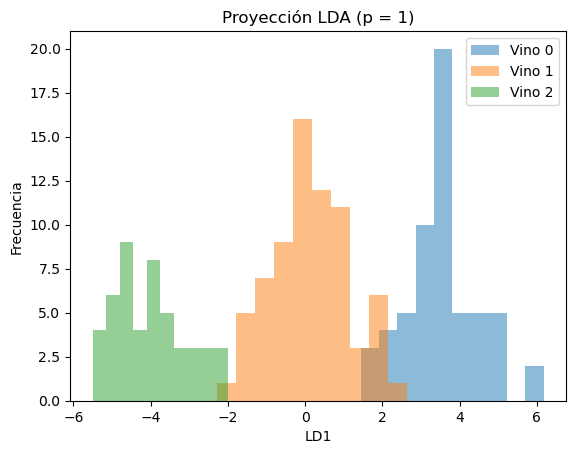

In [34]:
X_lda = lda_final.transform(X_std_vino)

if best_p == 1:
    plt.figure()
    for label in np.unique(y_vino):
        plt.hist(
            X_lda[y_vino == label],
            alpha=0.5,
            label=f'Vino {label}'
        )
    plt.xlabel('LD1')
    plt.ylabel('Frecuencia')
    plt.title('Proyección LDA (p = 1)')
    plt.legend()
    plt.show()

else:
    plt.figure(figsize=(8,6))
    for label in np.unique(y_vino):
        plt.scatter(
            X_lda[y == label, 0],
            X_lda[y == label, 1],
            label=f'Vino {label}',
            alpha=0.7
        )
    plt.xlabel('LD1')
    plt.ylabel('LD2')
    plt.title('Proyección LDA (p = 2)')
    plt.legend()
    plt.show()


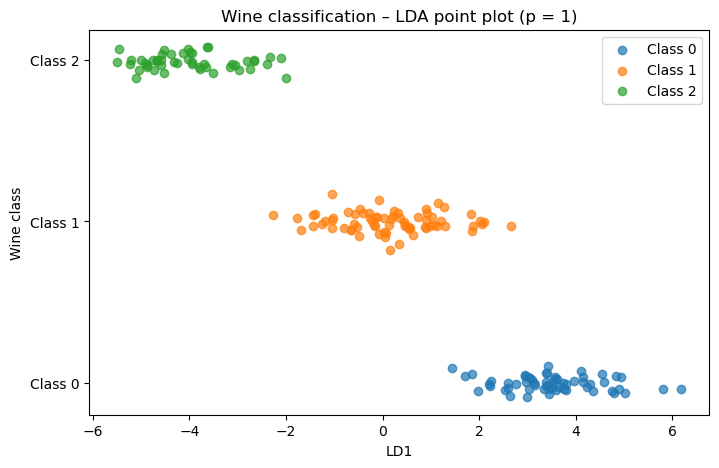

In [35]:
# LDA projection (p = 1)
X_lda = lda_final.transform(X_std_vino)

plt.figure(figsize=(8, 5))

for c in np.unique(y_vino):
    y_jitter = np.random.normal(loc=c, scale=0.05, size=(y_vino == c).sum())
    plt.scatter(
        X_lda[y_vino == c, 0],
        y_jitter,
        alpha=0.7,
        label=f'Class {c}'
    )

plt.xlabel('LD1')
plt.yticks(np.unique(y_vino), [f'Class {c}' for c in np.unique(y_vino)])
plt.ylabel('Wine class')
plt.title('Wine classification – LDA point plot (p = 1)')
plt.legend()
plt.show()


In [36]:
y_pred_final = lda_final.predict(X_test_v)
accuracy_score(y_test_v, y_pred_final)

1.0

In [37]:
cm = confusion_matrix(y_test_v, y_pred_final)
n_classes = cm.shape[0]

for i in range(n_classes):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - (TP + FN + FP)

    sensibilidad = TP / (TP + FN) if (TP+FN)!=0 else 0
    especificidad = TN / (TN + FP) if (TN+FP)!=0 else 0

    print(f"\nClase {i}")
    print(f"TP: {TP}, FP: {FP}, FN: {FN}, TN: {TN}")
    print(f"Sensibilidad: {sensibilidad:.4f}")
    print(f"Especificidad: {especificidad:.4f}")



Clase 0
TP: 17, FP: 0, FN: 0, TN: 19
Sensibilidad: 1.0000
Especificidad: 1.0000

Clase 1
TP: 11, FP: 0, FN: 0, TN: 25
Sensibilidad: 1.0000
Especificidad: 1.0000

Clase 2
TP: 8, FP: 0, FN: 0, TN: 28
Sensibilidad: 1.0000
Especificidad: 1.0000


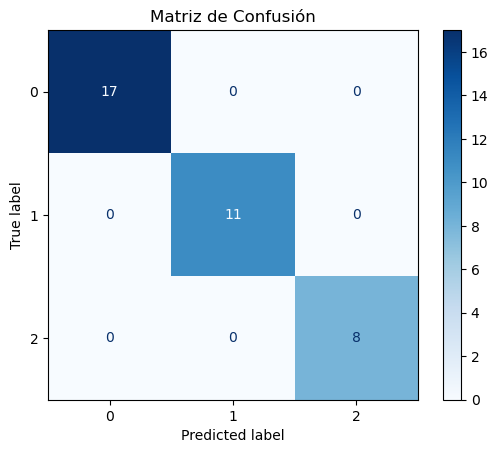

In [38]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de Confusión")
plt.show()

In [39]:
for rs in [0, 1, 10, 100]:
    X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(
        X_std_vino, y_vino, test_size=0.2, random_state=rs
    )
    lda = LinearDiscriminantAnalysis(n_components=1)
    lda.fit(X_train_v, y_train_v)
    acc = accuracy_score(y_test_v, lda.predict(X_test_v))
    print(rs, acc)

0 0.9722222222222222
1 1.0
10 0.9444444444444444
100 0.9722222222222222


El método de LDA nos permite clasificar los vinos de manera satisfactoria. <br>
Tambien se puede ver con otros random state que el modelo esta por arriba del 90% de predicción.